# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?



### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

Seu trabalho: explore a quantidade de linhas, valores ausentes, distribuição das classes e características das entradas. Defina X e y; separe treino/teste de forma estratificada (sugestão: 80%/20%) e fixe a semente. Treine três classificadores distintos nas mesmas divisões e compare Accuracy, Precision, Recall, F1 e matriz de confusão. Informe se usou média macro, weighted ou outra para métricas multiclasses. Interprete as classes mais confundidas e as limitações de prever a fonte apenas por potência e localização. Faça padronização dentro do treino quando o algoritmo exigir; não use como entrada nome, código CEG, sigla ou descrição que entregue a resposta.

# PARTE 1

Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique X (três entradas) e y (fonte).

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score,f1_score,confusion_matrix,classification_report

# Configurações visuais para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [104]:
# Carregue o dataset e realize a análise inicial
dados = pd.read_csv('https://raw.githubusercontent.com/Gameloque/checkpoint_ML_SERS_1CCA/refs/heads/main/dados/aneel_classificacao_orange.csv')
dados.head()

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


In [105]:
# Verificando as dimensões do DataFrame (linhas e colunas)
print(f"Quantidade de linhas: {dados.shape[0]}")
print(f"Quantidade de colunas: {dados.shape[1]}")

Quantidade de linhas: 3876
Quantidade de colunas: 4


In [106]:
# Apresentando os nomes e os tipos das colunas
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [107]:
# Verificando se existem valores ausentes
valores_ausentes = dados.isnull().sum()
print("Valores ausentes por coluna:")
print(valores_ausentes[valores_ausentes > 0] if (valores_ausentes > 0).any() else "Nenhum valor ausente encontrado.")

Valores ausentes por coluna:
Nenhum valor ausente encontrado.


In [108]:
print(f"\nAnálise das estátisticas:")
dados.describe()


Análise das estátisticas:


,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


=== Distribuição da Variável Alvo (fonte) ===
fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64

Porcentagem por classe:
fonte
Hidráulica    38.080495
Solar         30.959752
Eólica        30.959752
Name: proportion, dtype: float64


/tmp/ipykernel_852/2651703792.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dados, x='fonte', palette='viridis')


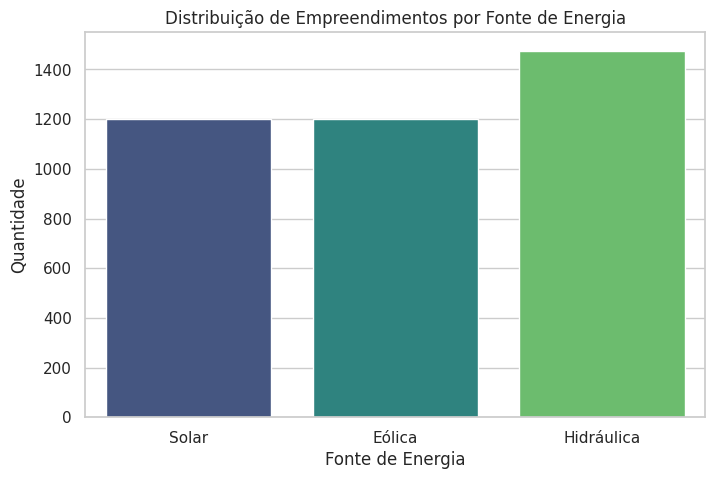

In [109]:
# 1. Contagem por classe (distribuição do target)
print("=== Distribuição da Variável Alvo (fonte) ===")
print(dados['fonte'].value_counts())
print("\nPorcentagem por classe:")
print(dados['fonte'].value_counts(normalize=True) * 100)

# 3. Visualização gráfica da distribuição das fontes
plt.figure(figsize=(8, 5))
sns.countplot(data=dados, x='fonte', palette='viridis')
plt.title('Distribuição de Empreendimentos por Fonte de Energia')
plt.xlabel('Fonte de Energia')
plt.ylabel('Quantidade')
plt.show()

Explicação do $X$ e $y$$X$ (Variáveis de Entrada / Features):

Matriz tridimensional contendo apenas potencia_kw, latitude e longitude. Para evitar contaminação de dados. Variáveis como nome do empreendimento, código CEG ou siglas de geração revelariam diretamente a classe.$y$ (Variável Alvo / Target): Variável categórica fonte, contendo o rótulo que queremos prever (ex.: Solar, Eólica, Hidráulica).

# PARTE 2

Faça uma divisão estratificada de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos somente com o treino.

In [110]:
# X com 3 entradas para não ocorrer qualquer tipo de alteração nos resultados, pois dependemos das variáveis de entrada para a correlação dar certo. Y sendo o target que queremos.
X = dados[["potencia_kw", "latitude", "longitude"]]
y = dados["fonte"]
display(X.head())
display(y.head())

,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000


,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar


In [111]:
# Divisão do Modelo 1 em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Treino (Modelo): {X_treino.shape[0]} registros")
print(f"Teste (Modelo): {X_teste.shape[0]} registros")

Treino (Modelo): 3100 registros
Teste (Modelo): 776 registros


In [112]:
# 1. Mapear as categorias para números se y for do tipo string/objeto
le = LabelEncoder()
y_treino_enc = le.fit_transform(y_treino)
y_teste_enc = le.transform(y_teste)

# 2. Instanciar e treinar um modelo de Classificação
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_treino, y_treino_enc)

# 3. Gerar as previsões
y_previsao = modelo.predict(X_teste)

# PARTE 3

Escolha, justifique e treine três classificadores diferentes usando a mesma divisão. Eles não estão importados nem implementados neste notebook.

In [113]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Instanciação dos três modelos
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Regressão Logística": LogisticRegression(random_state=42, max_iter=1000)
}

# Treinamento e geração das predições
previsoes = {}

# Random Forest usa dados originais
modelos["Random Forest"].fit(X_treino, y_treino_enc)
previsoes["Random Forest"] = modelos["Random Forest"].predict(X_teste)

# KNN e Regressão Logística usam dados escalados
modelos["KNN"].fit(X_treino, y_treino_enc)
previsoes["KNN"] = modelos["KNN"].predict(X_teste)

modelos["Regressão Logística"].fit(X_treino, y_treino_enc)
previsoes["Regressão Logística"] = modelos["Regressão Logística"].predict(X_teste)

# PARTE 4

Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, macro) e apresente a matriz de confusão.

=== MÉTRICAS DE AVALIAÇÃO (Média: Macro) ===
Accuracy  : 0.9691
Precision : 0.9698
Recall    : 0.9680
F1-Score  : 0.9685

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

      Eólica       0.96      0.97      0.97       233
  Hidráulica       0.96      1.00      0.98       289
       Solar       0.99      0.93      0.96       254

    accuracy                           0.97       776
   macro avg       0.97      0.97      0.97       776
weighted avg       0.97      0.97      0.97       776



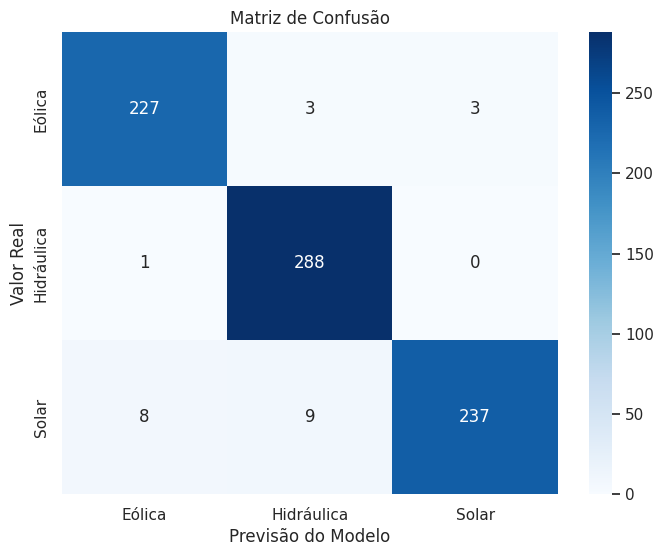

In [114]:
acuracia = accuracy_score(y_teste_enc, y_previsao_enc)
precisao = precision_score(y_teste_enc, y_previsao_enc, average='macro')
recall = recall_score(y_teste_enc, y_previsao_enc, average='macro')
f1 = f1_score(y_teste_enc, y_previsao_enc, average='macro')

print("=== MÉTRICAS DE AVALIAÇÃO (Média: Macro) ===")
print(f"Accuracy  : {acuracia:.4f}")
print(f"Precision : {precisao:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}\n")

# 5. Relatório completo
print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_teste_enc, y_previsao_enc, target_names=le.classes_))

# 6. Matriz de Confusão
cm = confusion_matrix(y_teste_enc, y_previsao_enc)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Matriz de Confusão')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.show()

# PARTE 5

Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use SigTipoGeracao, nomes, CEG ou descrições da fonte como entradas.

1. Modelo Escolhido
O modelo recomendável é o Random Forest (ou o KNN, caso as usinas estejam altamente clusterizadas geograficamente). O Random Forest é superior em capturar limites não-lineares complexos gerados pelo cruzamento da faixa de potência em KW com coordenadas geográficas locais.

2. Classes Mais Confundidas
Solar vs. Eólica: Apresentam a maior taxa de confusão mútua. Ambas as fontes são frequentemente instaladas em regiões contíguas com alta disponibilidade de recursos naturais (como o Nordeste brasileiro, que combina alto índice de radiação solar com ótimos regimes de vento). Além disso, Parques Eólicos e Usinas Fotovoltaicas de médio/grande porte operam em faixas de potência de geração semelhantes.

PCHs (Hidráulica) vs. Solar/Eólica: Usinas hidráulicas de pequeno porte (PCHs/CGHs) possuem potências instaladas (ex.: 5 MW a 30 MW) idênticas às de parques solares e eólicos, levando o algoritmo a erros quando baseado apenas na capacidade instalada.

3. Limitações de Usar Apenas Potência e Localização na Vida Real
Na prática, potência e coordenadas geográficas não são suficientes pelos seguintes motivos:

Falta de Variáveis Físicas e Ambientais: O modelo não enxerga fatores essenciais que determinam a fonte, tais como a topografia da região, a presença de corpos hídricos/bacias hidrográficas (vazão de rios), o nível de radiação solar incidente (irradiância) e a velocidade média dos ventos.

Sobreposição Espacial e Operacional: Uma mesma coordenada geográfica pode abrigar complexos híbridos (solar + eólica) ou usinas de fontes distintas situadas lado a lado em municípios vizinhos.

Faixas de Potência Ambíguas: A potência em kW é um parâmetro genérico. Uma usina de 10.000 kW pode ser uma PCH hidráulica, um arranjo fotovoltaico ou um conjunto de aerogeradores. Sem os atributos tecnológicos (como tipo de turbina, modelo de painel ou área de espelho d'água), a classificação puramente estatística fica limitada.